In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PREDICTIONS_FILE = "../logs/classification/predictions.csv"
SNAPSHOT_FILE = "../data/snapshot.parquet"
ALL_HORIZONS = ["1d", "1w", "1m", "6m", "1y", "3y", "5y"]
FOCUS_HORIZONS = ["6m", "1y", "5y"]
MODELS = ["logistic_regression", "random_forest", "gradient_boosting", "mlpclassifier"]
RETURN_COLS = [f"ret_{h}" for h in ALL_HORIZONS]
TOP_N = 20

In [28]:
# Load predictions
predictions = pd.read_csv(PREDICTIONS_FILE, parse_dates=["date"])
predictions["horizon"] = pd.Categorical(predictions["horizon"], categories=ALL_HORIZONS, ordered=True)

print(f"Loaded {len(predictions)} rows | {predictions['ticker'].nunique()} tickers | "
      f"{predictions['horizon'].nunique()} horizons | {predictions['model'].nunique()} models")
print(f"Snapshot date: {predictions['date'].max()}")
predictions.head()

Loaded 139104 rows | 4968 tickers | 7 horizons | 4 models
Snapshot date: 2026-07-30 00:00:00


,ticker,date,horizon,model,pred_proba,predicted_label
0,MI,2026-07-30,1d,gradient_boosting,0.659051,1
1,NCLH,2026-07-30,1d,gradient_boosting,0.649264,1
2,RDCM,2026-07-30,1d,gradient_boosting,0.646960,1
3,ALNY,2026-07-30,1d,gradient_boosting,0.644288,1
4,CAPR,2026-07-30,1d,gradient_boosting,0.637860,1


In [29]:
# Filter to focus horizons
focus = predictions[predictions["horizon"].isin(FOCUS_HORIZONS)].copy()
focus["horizon"] = focus["horizon"].cat.remove_unused_categories()

print(f"Focused on {FOCUS_HORIZONS}: {len(focus)} rows")

Focused on ['6m', '1y', '5y']: 59616 rows


In [30]:
# Get top n results per model/horizon
top_selections = (
    focus.sort_values("pred_proba", ascending=False)
    .groupby(["horizon", "model"])
    .head(TOP_N)
    .reset_index(drop=True)
)
print(f"{len(top_selections)} top-{TOP_N} rows across "
      f"{top_selections.groupby(['horizon', 'model']).ngroups} horizon/model combos")
top_selections.head()

240 top-20 rows across 12 horizon/model combos


,ticker,date,horizon,model,pred_proba,predicted_label
0,CLS,2026-07-30,1y,logistic_regression,0.964473,1
1,LQDA,2026-07-30,1y,logistic_regression,0.961466,1
2,CLS,2026-07-30,5y,logistic_regression,0.948898,1
3,CKHGF,2026-07-30,1y,logistic_regression,0.935693,1
4,CLS,2026-07-30,6m,logistic_regression,0.929544,1


In [31]:
# Select most frequently selected tickers
ticker_counts = (
    top_selections.groupby("ticker")
    .agg(
        times_selected=("ticker", "size"),
        n_horizons=("horizon", "nunique"),
        n_models=("model", "nunique"),
        avg_pred_proba=("pred_proba", "mean"),
    )
    .sort_values("times_selected", ascending=False)
)
ticker_counts.head(20)

,times_selected,n_horizons,n_models,avg_pred_proba
ticker,,,,
SMCI,5,2,3,0.730121
CRS,4,3,2,0.714289
CLS,3,3,1,0.947638
CKHGF,3,3,1,0.910328
CLH,3,2,2,0.517533
FIX,3,3,1,0.837740
MOD,3,3,1,0.700824
BELFB,3,3,1,0.815698
BELFA,3,3,1,0.742445


In [32]:
# Check agreement between model within a horizon
agreement = (
    top_selections.groupby(["horizon", "ticker"])
    .agg(n_models=("model", "nunique"), models=("model", lambda s: sorted(s.unique())))
    .reset_index()
)
agreement = agreement[agreement["n_models"] > 1].sort_values(
    ["horizon", "n_models"], ascending=[True, False]
)
agreement

,horizon,ticker,n_models,models
56,6m,SMCI,3,"[gradient_boosting, logistic_regression, mlpcl..."
0,6m,ACMR,2,"[gradient_boosting, mlpclassifier]"
15,6m,CLH,2,"[mlpclassifier, random_forest]"
22,6m,EOLS,2,"[gradient_boosting, random_forest]"
50,6m,PNDRY,2,"[mlpclassifier, random_forest]"
53,6m,PRCH,2,"[gradient_boosting, random_forest]"
68,6m,WSC,2,"[mlpclassifier, random_forest]"
87,1y,CRS,2,"[logistic_regression, mlpclassifier]"
103,1y,KINS,2,"[gradient_boosting, mlpclassifier]"
112,1y,NCLTF,2,"[gradient_boosting, random_forest]"


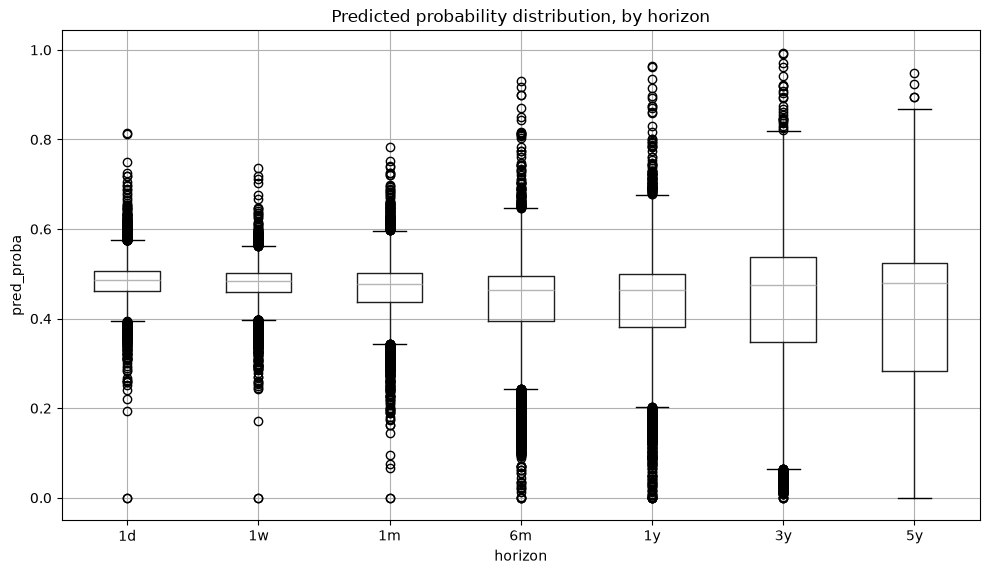

In [33]:
# Predicted probability distribution for all horizons
fig, ax = plt.subplots(figsize=(10, 6))
predictions.boxplot(column="pred_proba", by="horizon", ax=ax)
plt.title("Predicted probability distribution, by horizon")
plt.suptitle("")
plt.ylabel("pred_proba")
plt.tight_layout()
plt.show()

In [34]:
# Side by side comparison for one horizon
def compare_models_for_horizon(horizon):
    sub = focus[focus["horizon"] == horizon]
    pivot = sub.pivot_table(index="ticker", columns="model", values="pred_proba")
    pivot["n_models_present"] = pivot.notna().sum(axis=1)
    pivot["avg_pred_proba"] = pivot[MODELS].mean(axis=1)
    return pivot.sort_values(["n_models_present", "avg_pred_proba"], ascending=False)

compare_models_for_horizon("5y").head(20)

model,gradient_boosting,logistic_regression,mlpclassifier,random_forest,n_models_present,avg_pred_proba
ticker,,,,,,
JFIN,0.869094,0.499880,0.352017,0.677390,4,0.599595
WAB,0.755063,0.526352,0.406220,0.649848,4,0.584371
IMO,0.760970,0.555723,0.367989,0.648105,4,0.583197
AMAL,0.747693,0.523108,0.402199,0.650927,4,0.580982
TK,0.727325,0.556342,0.362200,0.645607,4,0.572868
WGS,0.894279,0.506611,0.274189,0.615313,4,0.572598
WMB,0.711460,0.535686,0.404231,0.630710,4,0.570522
IFS,0.721019,0.526899,0.390786,0.640379,4,0.569771
GSL,0.746044,0.520333,0.369113,0.642041,4,0.569383


In [37]:
snapshot = pd.read_parquet(SNAPSHOT_FILE)

top10 = (
    focus.sort_values("pred_proba", ascending=False)
    .groupby(["horizon", "model"])
    .head(10)
    .reset_index(drop=True)
)

top10 = top10.merge(
    snapshot[["ticker"] + RETURN_COLS],
    on="ticker",
    how="left",
)

top10 = top10.sort_values(
    ["horizon", "model", "pred_proba"], ascending=[True, True, False]
).reset_index(drop=True)


def color_returns(val):
    if pd.isna(val):
        return ""
    color = "green" if val > 0 else "red" if val < 0 else "black"
    return f"color: {color}"


format_dict = {col: "{:.2%}" for col in RETURN_COLS}
format_dict["pred_proba"] = "{:.2%}"

for horizon in FOCUS_HORIZONS:
    for model in MODELS:
        subset = top10[(top10["horizon"] == horizon) & (top10["model"] == model)]
        if subset.empty:
            continue
        print(f"\n=== {horizon} — {model} ===")

        styled = (
            subset[["ticker", "pred_proba", "predicted_label"] + RETURN_COLS]
            .style
            .map(color_returns, subset=RETURN_COLS)
            .format(format_dict)
            .hide(axis="index")
        )
        display(styled)


=== 6m — logistic_regression ===


ticker,pred_proba,predicted_label,ret_1d,ret_1w,ret_1m,ret_6m,ret_1y,ret_3y,ret_5y
CLS,92.95%,1,7.36%,5.33%,-3.35%,2.13%,74.20%,1601.69%,3875.08%
LQDA,91.67%,1,-0.02%,-2.50%,8.87%,107.11%,354.21%,1018.56%,3673.91%
CKHGF,89.94%,1,0.00%,10.48%,10.48%,109.39%,148.42%,927.65%,3028.32%
STRL,87.05%,1,17.50%,-19.04%,-30.81%,55.47%,120.52%,888.48%,2544.49%
NSKFF,84.99%,1,1.01%,2.75%,6.21%,7.22%,40.88%,444.56%,2290.59%
POWL,81.34%,1,12.29%,-13.68%,-26.91%,41.71%,172.99%,949.73%,2259.84%
FIX,81.26%,1,11.70%,-7.28%,-14.33%,45.36%,142.07%,887.17%,2220.50%
BELFB,80.76%,1,4.53%,-11.37%,-23.89%,22.03%,101.54%,344.63%,1827.29%
BELFA,73.42%,1,3.60%,-13.10%,-27.97%,10.07%,89.01%,245.26%,1297.09%
VIST,73.25%,1,3.88%,-0.71%,7.48%,15.36%,50.90%,166.71%,1340.55%



=== 6m — random_forest ===


ticker,pred_proba,predicted_label,ret_1d,ret_1w,ret_1m,ret_6m,ret_1y,ret_3y,ret_5y
CAR,58.68%,1,-1.84%,-4.43%,2.82%,32.06%,-11.86%,-28.08%,93.28%
BSVN,58.30%,1,-0.64%,-0.79%,2.15%,15.54%,13.66%,109.44%,196.82%
TLPPF,58.28%,1,-1.58%,-5.24%,-11.69%,24.39%,-25.51%,27.28%,132.65%
ET,58.21%,1,0.20%,-0.88%,5.86%,15.00%,20.81%,93.74%,204.72%
EOLS,58.21%,1,-0.33%,0.33%,-13.40%,25.21%,-32.92%,-40.67%,-44.45%
UNTY,57.96%,1,-0.20%,3.17%,-0.03%,14.18%,19.40%,134.34%,185.39%
FWONA,57.95%,1,-1.61%,3.70%,5.08%,14.44%,-0.10%,46.74%,131.74%
PFGC,57.86%,1,-1.63%,4.03%,2.65%,17.84%,12.41%,89.29%,150.44%
STVN,57.84%,1,-1.03%,4.12%,11.79%,26.55%,-18.71%,-34.59%,1.56%
PDX,57.77%,1,0.28%,-0.80%,2.17%,9.89%,6.79%,82.53%,195.47%



=== 6m — gradient_boosting ===


...

ticker,pred_proba,predicted_label,ret_1d,ret_1w,ret_1m,ret_6m,ret_1y,ret_3y,ret_5y
CAPR,67.94%,1,-36.23%,-78.87%,-82.60%,-80.57%,-48.78%,-7.51%,-4.12%
JFIN,67.74%,1,0.91%,-0.45%,-22.73%,-68.29%,-83.64%,-62.73%,-29.17%
SSTK,66.57%,1,-5.61%,-6.60%,-61.43%,-70.96%,-70.40%,-87.54%,-94.01%
LSTA,66.32%,1,-5.50%,-51.42%,-69.71%,-77.51%,-59.29%,-67.30%,-94.84%
SOHOO,66.17%,1,0.00%,0.00%,3.80%,-82.39%,-79.50%,-83.46%,-76.37%
ALAR,65.88%,1,-1.76%,-13.92%,-79.23%,-78.81%,-85.76%,-22.33%,-85.85%
AMAL,65.09%,1,0.28%,1.50%,7.60%,32.29%,71.76%,161.57%,252.45%
WAB,64.98%,1,0.24%,-1.86%,8.48%,28.08%,54.17%,150.46%,254.36%
EXEL,64.91%,1,1.16%,0.58%,2.87%,31.20%,51.89%,181.96%,232.17%
IMO,64.81%,1,0.00%,-0.02%,14.98%,25.77%,56.15%,156.76%,433.51%



=== 5y — gradient_boosting ===


ticker,pred_proba,predicted_label,ret_1d,ret_1w,ret_1m,ret_6m,ret_1y,ret_3y,ret_5y
WGS,89.43%,1,8.28%,8.80%,0.45%,-27.63%,-33.38%,865.83%,-81.47%
JFIN,86.91%,1,0.91%,-0.45%,-22.73%,-68.29%,-83.64%,-62.73%,-29.17%
OKUR,83.41%,1,1.27%,-5.21%,-12.28%,41.34%,75.44%,-94.94%,-95.12%
BETR,80.43%,1,2.60%,-2.39%,-22.62%,-33.25%,60.97%,-99.03%,-95.71%
CVNA,79.95%,1,-7.36%,2.08%,-6.65%,-25.08%,-7.91%,597.86%,-2.86%
BNED,79.87%,1,-1.11%,4.99%,-0.49%,39.49%,40.91%,-90.00%,-98.50%
YI,78.91%,1,8.15%,1.32%,-11.29%,-27.63%,-44.44%,34.15%,-81.08%
SEDG,77.56%,1,6.97%,-7.49%,-28.54%,16.65%,61.80%,-82.36%,-83.91%
FNCHQ,77.43%,1,0.00%,-4.00%,-4.95%,-30.18%,-23.20%,11.89%,-97.59%
GOGO,77.20%,1,6.57%,9.68%,33.39%,-8.92%,-74.83%,-73.86%,-60.13%



=== 5y — mlpclassifier ===


ticker,pred_proba,predicted_label,ret_1d,ret_1w,ret_1m,ret_6m,ret_1y,ret_3y,ret_5y
WDC,47.75%,0,15.37%,-4.52%,-16.55%,90.72%,648.26%,1585.56%,991.08%
LITE,42.29%,0,15.09%,-16.84%,-19.21%,80.06%,531.08%,1223.99%,725.38%
PRAX,42.09%,0,5.75%,-4.54%,-8.08%,-0.70%,443.82%,1993.54%,31.52%
WAB,40.62%,0,0.24%,-1.86%,8.48%,28.08%,54.17%,150.46%,254.36%
WMB,40.42%,0,1.11%,-5.77%,-4.61%,7.51%,23.50%,134.30%,255.99%
AMAL,40.22%,0,0.28%,1.50%,7.60%,32.29%,71.76%,161.57%,252.45%
DHT,40.09%,0,0.00%,0.76%,12.22%,42.59%,75.79%,142.45%,339.23%
PH,39.74%,0,1.23%,-2.30%,-1.57%,5.51%,32.67%,148.81%,229.09%
FBIZ,39.72%,0,-0.47%,1.88%,6.47%,22.77%,44.46%,112.15%,176.35%
PAGP,39.22%,0,-0.26%,0.30%,9.56%,32.34%,45.57%,110.03%,259.35%
